# Projeto Integrador I - O Peso das Palavras
## Análise Exploratória e de Sentimentos em Marketplace (AWS)

**Disciplina:** Projeto Integrador I (PII1) · **Professor:** Prof. Dr. Felipe A. Camargo  
**Autores:** _Anderson Horácio, Felipe dos Santos, Giovanna Xavier, Guilherme Vilanova_

---

### Contexto e problema de negócio

Em marketplaces, a satisfação é expressa por **nota (1–5)** e **comentário textual**. Nem sempre ambos convergem, o que dificulta métricas automáticas de satisfação.

### Objetivo

Investigar a relação entre `review_score` e `review_comment_message`, identificando padrões, incoerências e comportamento dos clientes.

### Abordagem de sentimento (destaque)

A análise principal usa **Transformers (Hugging Face)**, modelo **BERT multilíngue** que processa português **sem tradução externa**. VADER e LeIA aparecem apenas como **referência comparativa** (modelos léxicos).

### Tabelas do projeto (9 CSV)

`pedidos`, `itens_pedidos`, `pagamentos`, `avaliacoes` (foco), `clientes`, `vendedores`, `produtos`, `geolocalizacao`, `tabela_auxiliar`.

### Fluxo do notebook

1. Carregamento → 2. Entendimento → 3. **Limpeza** → 4. **Features** → 5. **EDA** → 6. NLP → 7. Sentimentos → 8. Conclusões

### Execução no Colab

1. **Runtime → Change runtime type → T4 GPU**  
2. Envie a pasta `banco de dados` ao Drive ou faça upload no Colab  
3. Ajuste `PASTA_DADOS` na célula de carregamento  
4. **Runtime → Run all** (Transformers na base completa: ~1–3 h com GPU)

## 2. Instalação e bibliotecas

In [3]:
# Instalação (Google Colab) — execute uma vez
import sys, subprocess

pacotes = [
    "pandas", "numpy", "matplotlib", "seaborn", "plotly",
    "nltk", "wordcloud", "vaderSentiment", "leia-br",
    "transformers", "torch", "accelerate", "tqdm",
    "scikit-learn", "scipy", "unidecode", "emoji",
]
for p in pacotes:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p], check=False)

import nltk
for r in ["punkt", "punkt_tab", "stopwords", "rslp"]:
    try:
        nltk.download(r, quiet=True)
    except Exception:
        pass
print("Pacotes instalados.")

Pacotes instalados.


In [4]:
import warnings
import re
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import cohen_kappa_score
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
from wordcloud import WordCloud
import emoji
from unidecode import unidecode

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

CORES_NOTA = {1: "#d62728", 2: "#ff7f0e", 3: "#bcbd22", 4: "#2ca02c", 5: "#1f77b4"}
print("Bibliotecas carregadas:", datetime.now().strftime("%Y-%m-%d %H:%M"))

Bibliotecas carregadas: 2026-06-03 18:11


In [5]:
sns.set_theme(style="whitegrid")

COR_PRIMARIA = "#1f4e79"      # azul
COR_SECUNDARIA = "#4f81bd"
COR_DESTAQUE = "#d62728"      # vermelho para atraso
COR_POSITIVO = "#2ca02c"
COR_NEUTRO = "#ffbf00"
COR_NEGATIVO = "#c0392b"

## 3. Carregamento dos dados

Ajuste `PASTA_DADOS` para o caminho da pasta que contém os 9 arquivos CSV.

In [6]:
# Montar Drive (Colab)
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

# === AJUSTE AQUI ===
PASTA_DADOS = None
for caminho in [
    "/content/drive/MyDrive/Banco_de_Dados_PII3_AWS/banco-de-dados",
    "/content/drive/MyDrive/banco-de-dados",
    "/content/banco-de-dados"
]:
    if os.path.isdir(caminho) and os.path.isfile(os.path.join(caminho, "avaliacoes.csv")):
        PASTA_DADOS = caminho
        break

if PASTA_DADOS is None:
    raise FileNotFoundError("Pasta 'banco de dados' não encontrada. Ajuste PASTA_DADOS.")

print("Pasta:", PASTA_DADOS)

def ler_csv(nome):
    path = os.path.join(PASTA_DADOS, nome)
    for enc in ("utf-8", "latin-1", "iso-8859-1"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, low_memory=False)

pedidos = ler_csv("pedidos.csv")
itens = ler_csv("itens_pedidos.csv")
clientes = ler_csv("clientes.csv")
produtos = ler_csv("produtos.csv")
pagamentos = ler_csv("pagamentos.csv")
avaliacoes = ler_csv("avaliacoes.csv")
vendedores = ler_csv("vendedores.csv")
geo = ler_csv("geolocalizacao.csv")
aux = ler_csv("tabela_auxiliar.csv")

tabelas = {
    "pedidos": pedidos, "itens_pedidos": itens, "clientes": clientes,
    "produtos": produtos, "pagamentos": pagamentos, "avaliacoes": avaliacoes,
    "vendedores": vendedores, "geolocalizacao": geo, "tabela_auxiliar": aux,
}

for nome, df in tabelas.items():
    print(f"{nome:20s} → {df.shape[0]:>8,} linhas × {df.shape[1]} colunas")

Mounted at /content/drive
Pasta: /content/drive/MyDrive/banco-de-dados
pedidos              →   99,441 linhas × 8 colunas
itens_pedidos        →  112,650 linhas × 7 colunas
clientes             →   99,441 linhas × 5 colunas
produtos             →   32,951 linhas × 9 colunas
pagamentos           →  103,886 linhas × 5 colunas
avaliacoes           →   99,224 linhas × 7 colunas
vendedores           →    3,095 linhas × 4 colunas
geolocalizacao       → 1,000,163 linhas × 5 colunas
tabela_auxiliar      →       71 linhas × 2 colunas


In [7]:
# Visão geral rápida — todas as tabelas
for nome, df in tabelas.items():
    print("=" * 60)
    print(nome.upper(), df.shape)
    display(df.head(3))
    print("Nulos (%):\n", (df.isna().mean() * 100).round(2))
    display(df.describe(include="all").T.head(12))

PEDIDOS (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


Nulos (%):
 order_id                         0.00
customer_id                      0.00
order_status                     0.00
order_purchase_timestamp         0.00
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
order_estimated_delivery_date    0.00
dtype: float64


,count,unique,top,freq
order_id,99441,99441,66dea50a8b16d9b4dee7af250b4be1a5,1
customer_id,99441,99441,edb027a75a1449115f6b43211ae02a24,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-08-02 12:06:07,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-14 20:02:44,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


ITENS_PEDIDOS (112650, 7)


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,NaN,NaN,NaN,36574.166466,30549.33571,1001.0,11075.0,26530.0,63504.0,99990.0
geolocation_lat,1000163.0,NaN,NaN,NaN,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.97962,45.065933
geolocation_lng,1000163.0,NaN,NaN,NaN,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN


TABELA_AUXILIAR (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


Nulos (%):
 product_category_name            0.0
product_category_name_english    0.0
dtype: float64


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


## 4. Entendimento das tabelas

**Pergunta guia:** como os dados se conectam para explicar a jornada do cliente até a avaliação?

**Fluxo:** cliente → pedido → itens / pagamento → avaliação  
**Chave central:** `order_id`

| Tabela | Papel |
|--------|-------|
| avaliacoes | Nota + texto (foco do projeto) |
| pedidos | Datas de compra e entrega (prazo) |
| clientes | Estado/região do comprador |
| itens_pedidos | Itens por pedido |

In [8]:
pedidos_ids = set(pedidos["order_id"])
print("Integridade — chaves órfãs:")
print("  Avaliações sem pedido:", (~avaliacoes["order_id"].isin(pedidos_ids)).sum())
print("  Itens sem pedido:", (~itens["order_id"].isin(pedidos_ids)).sum())
print("  Pagamentos sem pedido:", (~pagamentos["order_id"].isin(pedidos_ids)).sum())

Integridade — chaves órfãs:
  Avaliações sem pedido: 0
  Itens sem pedido: 0
  Pagamentos sem pedido: 0


## 5. Limpeza e tratamento dos dados

Todas as análises seguintes usam **dados já tratados**. Nenhuma amostragem — apenas duplicatas e padronização.

**Texto consolidado:** quando o comentário estiver vazio, usamos o **título** como fallback (`texto_final_avaliacao`), conforme orientação do professor.

In [9]:
# ==========================================================
# LIMPEZA E PREPARAÇÃO DAS AVALIAÇÕES
# ==========================================================

# Remover duplicatas
n_dup = avaliacoes.duplicated(subset=["review_id"]).sum()
avaliacoes = avaliacoes.drop_duplicates(
    subset=["review_id"],
    keep="first"
)

print(f"Duplicatas removidas em avaliacoes: {n_dup}")

# ==========================================================
# CONVERSÃO DE DATAS
# ==========================================================

for col in ["review_creation_date", "review_answer_timestamp"]:
    avaliacoes[col] = pd.to_datetime(
        avaliacoes[col],
        errors="coerce"
    )

for col in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    if col in pedidos.columns:
        pedidos[col] = pd.to_datetime(
            pedidos[col],
            errors="coerce"
        )

# ==========================================================
# TRATAMENTO DOS TEXTOS
# ==========================================================

avaliacoes["review_comment_title"] = (
    avaliacoes["review_comment_title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

avaliacoes["review_comment_message"] = (
    avaliacoes["review_comment_message"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# ==========================================================
# CONCATENAÇÃO DE TÍTULO + COMENTÁRIO
# (ABORDAGEM DO PROFESSOR)
# ==========================================================

avaliacoes["texto_final_avaliacao"] = (
    avaliacoes["review_comment_title"]
    + " "
    + avaliacoes["review_comment_message"]
)

# Remover espaços duplicados
avaliacoes["texto_final_avaliacao"] = (
    avaliacoes["texto_final_avaliacao"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Converter texto vazio para NaN
avaliacoes["texto_final_avaliacao"] = (
    avaliacoes["texto_final_avaliacao"]
    .replace("", pd.NA)
)

# ==========================================================
# INDICADOR DE USO DO TÍTULO COMO FALLBACK
# ==========================================================

avaliacoes["usou_titulo_fallback"] = (
    (avaliacoes["review_comment_message"].str.len() == 0)
    &
    (avaliacoes["review_comment_title"].str.len() > 0)
)

# ==========================================================
# ESTATÍSTICAS
# ==========================================================

print(
    f"Avaliações com comentário: "
    f"{(avaliacoes['review_comment_message'].str.len() > 0).sum():,}"
)

print(
    f"Avaliações com título: "
    f"{(avaliacoes['review_comment_title'].str.len() > 0).sum():,}"
)

print(
    f"Avaliações usando apenas título: "
    f"{avaliacoes['usou_titulo_fallback'].sum():,}"
)

print(
    f"Avaliações com texto para análise: "
    f"{avaliacoes['texto_final_avaliacao'].notna().sum():,}"
)

# ==========================================================
# PADRONIZAÇÃO DE LOCALIZAÇÃO
# ==========================================================

clientes["customer_state"] = (
    clientes["customer_state"]
    .astype(str)
    .str.upper()
    .str.strip()
)

if "customer_city" in clientes.columns:
    clientes["customer_city"] = (
        clientes["customer_city"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

print("Limpeza concluída.")

# ==========================================================
# EXEMPLOS PARA CONFERÊNCIA
# ==========================================================

display(
    avaliacoes[
        [
            "review_comment_title",
            "review_comment_message",
            "texto_final_avaliacao",
            "usou_titulo_fallback"
        ]
    ].head(10)
)

Duplicatas removidas em avaliacoes: 814
Avaliações com comentário: 40,641
Avaliações com título: 11,517
Avaliações usando apenas título: 1,729
Avaliações com texto para análise: 42,370
Limpeza concluída.


,review_comment_title,review_comment_message,texto_final_avaliacao,usou_titulo_fallback
0,,,<NA>,False
1,,,<NA>,False
2,,,<NA>,False
3,,Recebi bem antes do prazo estipulado.,Recebi bem antes do prazo estipulado.,False
4,,Parabéns lojas lannister adorei comprar pela I...,Parabéns lojas lannister adorei comprar pela I...,False
5,,,<NA>,False
6,,,<NA>,False
7,,,<NA>,False
8,,,<NA>,False
9,recomendo,aparelho eficiente. no site a marca do aparelh...,recomendo aparelho eficiente. no site a marca ...,False


## 6. Variáveis derivadas
Criamos variáveis de **prazo**, **atraso** e **região** para investigar o impacto da entrega na satisfação.

In [10]:
# Prazo e atraso (pedidos entregues)
pedidos["dias_entrega"] = (
    pedidos["order_delivered_customer_date"] - pedidos["order_purchase_timestamp"]
).dt.days
pedidos["dias_atraso"] = (
    pedidos["order_delivered_customer_date"] - pedidos["order_estimated_delivery_date"]
).dt.days
pedidos["atrasou"] = (pedidos["dias_atraso"] > 0).astype(int)
pedidos["no_prazo"] = (pedidos["dias_atraso"] <= 0).astype(int)

# Faixas de atraso
pedidos["faixa_atraso"] = pd.cut(
    pedidos["dias_atraso"].fillna(0),
    bins=[-999, 0, 3, 7, 999],
    labels=["no_prazo", "atraso_leve", "atraso_medio", "atraso_grave"],
)

# Trimestre da compra (análise temporal de atrasos)
pedidos["trimestre"] = pedidos["order_purchase_timestamp"].dt.to_period("Q").astype(str)

# Agregação por pedido
agg_itens = itens.groupby("order_id").agg(
    qtd_itens=("order_item_id", "count"),
    valor_total=("price", "sum"),
).reset_index()

# Base analítica: 1 linha por avaliação (dados limpos)
base = avaliacoes.merge(pedidos, on="order_id", how="left")
base = base.merge(agg_itens, on="order_id", how="left")
base = base.merge(clientes[["customer_id", "customer_state"]], on="customer_id", how="left")

base["tam_texto"] = base["texto_final_avaliacao"].str.len()

print("Base analitica:", base.shape)
display(base[[
    "review_score", "texto_final_avaliacao", "usou_titulo_fallback",
    "dias_atraso", "atrasou", "faixa_atraso", "customer_state"
]].head())

Base analitica: (98410, 26)


,review_score,texto_final_avaliacao,usou_titulo_fallback,dias_atraso,atrasou,faixa_atraso,customer_state
0,4,<NA>,False,-16.0,0,no_prazo,SP
1,5,<NA>,False,-5.0,0,no_prazo,SP
2,5,<NA>,False,-21.0,0,no_prazo,BA
3,5,Recebi bem antes do prazo estipulado.,False,-20.0,0,no_prazo,SC
4,5,Parabéns lojas lannister adorei comprar pela I...,False,-9.0,0,no_prazo,SC


## 7. Análise exploratória (dados tratados)

**Hipóteses investigadas:**
1. Atraso na entrega reduz a nota?
2. Pedidos atrasados concentram avaliações piores?
3. Estados com mais atrasos também têm pior satisfação?
4. Em quais trimestres houve mais atrasos?

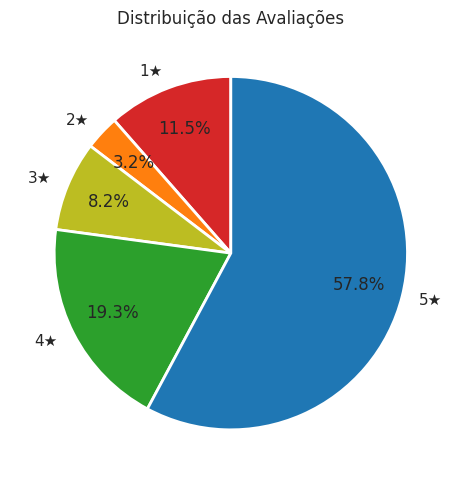

In [11]:
# Distribuição percentual das notas

dist_notas = (
    base["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(5, 5))

plt.pie(
    dist_notas,
    labels=[f"{i}★" for i in dist_notas.index],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    colors=[CORES_NOTA.get(i, "gray") for i in dist_notas.index],
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title("Distribuição das Avaliações")
plt.tight_layout()
plt.show()

Observa-se forte concentração de avaliações na nota 5.

Mais da metade dos clientes atribuíram a avaliação máxima, indicando predominância de experiências positivas.

As notas 1 e 2 representam parcela significativamente menor, sugerindo que casos de insatisfação são menos frequentes, porém relevantes para investigação de causas.

Pedidos com data de entrega: 95,607


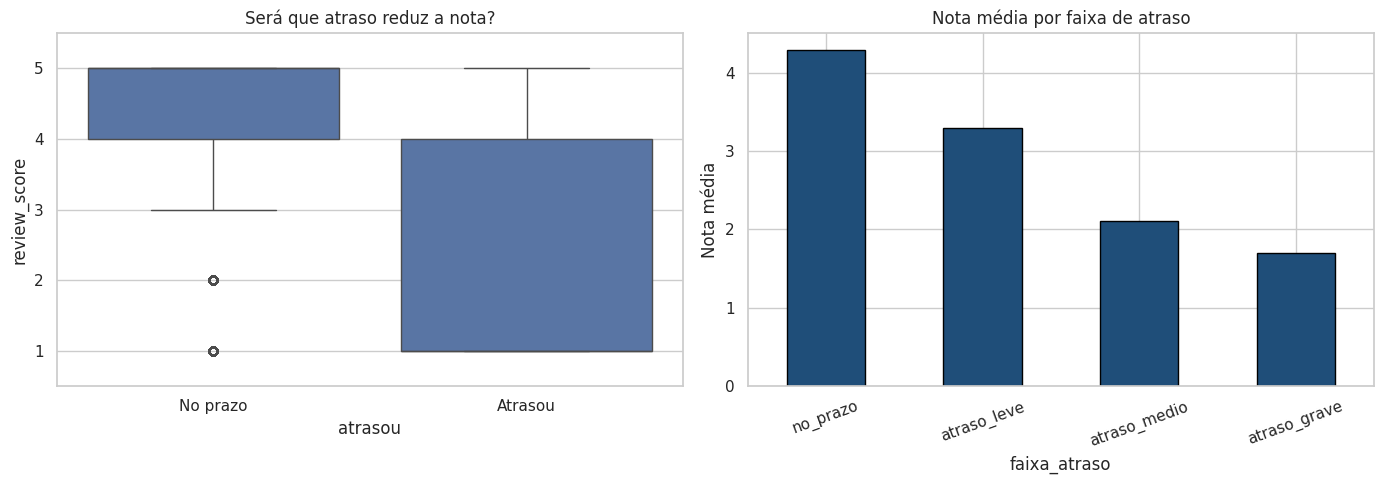

Correlacao dias_atraso x nota: -0.2673
% pedidos atrasados: 6.7%
Nota média — no prazo: 4.292 | atrasados: 2.27
Interpretação: atraso associa-se a notas menores; impacto mensurável na satisfação.


In [43]:
# 7.2 ENTREGA E ATRASO x NOTA
entregues = base[base["order_delivered_customer_date"].notna()].copy()
print(f"Pedidos com data de entrega: {len(entregues):,}")

# Atraso x nota
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=entregues, x="atrasou", y="review_score", ax=axes[0])
axes[0].set_xticklabels(["No prazo", "Atrasou"])
axes[0].set_title("Será que atraso reduz a nota?")
axes[0].set_yticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0.5, 5.5)

nota_faixa = entregues.groupby("faixa_atraso", observed=True)["review_score"].agg(["mean", "count"])
nota_faixa["mean"].plot(kind="bar", ax=axes[1], color=COR_PRIMARIA, edgecolor="black")
axes[1].set_title("Nota média por faixa de atraso"); axes[1].set_ylabel("Nota média")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

corr_atraso_nota = entregues["dias_atraso"].corr(entregues["review_score"])
pct_atraso = entregues["atrasou"].mean() * 100
nota_atraso = entregues.groupby("atrasou")["review_score"].mean()
print(f"Correlacao dias_atraso x nota: {corr_atraso_nota:.4f}")
print(f"% pedidos atrasados: {pct_atraso:.1f}%")
print("Nota média — no prazo:", round(nota_atraso.get(0, np.nan), 3),
      "| atrasados:", round(nota_atraso.get(1, np.nan), 3))
print("Interpretação: atraso associa-se a notas menores; impacto mensurável na satisfação.")

=== Estados: volume, atraso e satisfacao ===


,qtd_pedidos,pct_atraso,dias_atraso_medio,nota_media,qtd_avaliacoes
customer_state,,,,,
SP,41746,4.36,-11.076380,4.175629,41360
RJ,12852,11.63,-11.766858,3.880604,12647
MG,11635,4.47,-13.240775,4.138903,11526
RS,5466,5.95,-13.910367,4.136280,5430
PR,5045,3.94,-13.314239,4.184652,5004
SC,3637,8.00,-11.508317,4.076389,3600
BA,3380,11.72,-10.794533,3.862245,3332
DF,2140,5.51,-12.048077,4.069340,2120
ES,2033,10.53,-10.496241,4.039382,2006


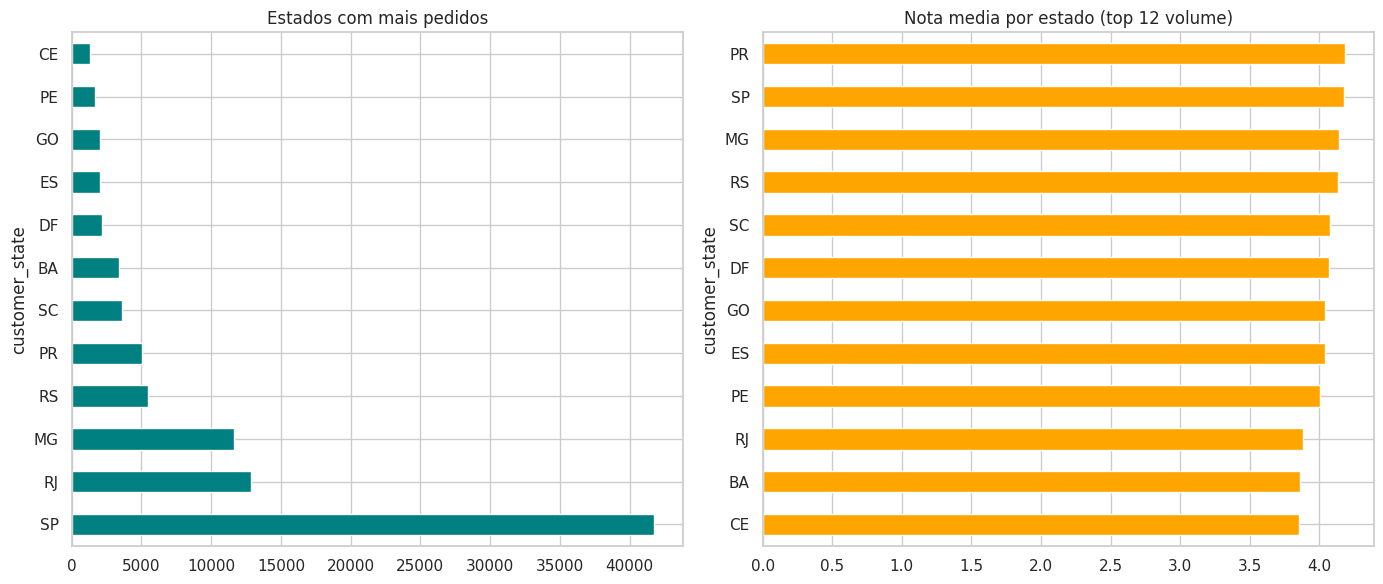

Estado com menor nota media: RR
Estado com maior % atraso: AL
Interpretacao: comparar volume, prazo e satisfacao fortalece leitura regional.


In [16]:
# 7.4 ANALISE REGIONAL — pedidos, atraso e satisfacao
ped_est = pedidos.merge(clientes[["customer_id", "customer_state"]], on="customer_id", how="left")
ped_est = ped_est[ped_est["customer_state"].notna() & (ped_est["customer_state"] != "nan")]

regiao_pedidos = ped_est.groupby("customer_state").agg(
    qtd_pedidos=("order_id", "count"),
    pct_atraso=("atrasou", "mean"),
    dias_atraso_medio=("dias_atraso", "mean"),
).sort_values("qtd_pedidos", ascending=False)

regiao_aval = base.groupby("customer_state").agg(
    nota_media=("review_score", "mean"),
    qtd_avaliacoes=("review_id", "count"),
).sort_values("qtd_avaliacoes", ascending=False)

regional = regiao_pedidos.join(regiao_aval, how="outer")
regional["pct_atraso"] = (regional["pct_atraso"] * 100).round(2)
regional = regional.sort_values("qtd_pedidos", ascending=False)

print("=== Estados: volume, atraso e satisfacao ===")
display(regional.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top = regional.head(12)
top["qtd_pedidos"].plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Estados com mais pedidos")
top["nota_media"].sort_values().plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Nota media por estado (top 12 volume)")
plt.tight_layout(); plt.show()

pior_nota = regional["nota_media"].idxmin()
maior_atraso = regional["pct_atraso"].idxmax()
print(f"Estado com menor nota media: {pior_nota}")
print(f"Estado com maior % atraso: {maior_atraso}")
print("Interpretacao: comparar volume, prazo e satisfacao fortalece leitura regional.")

## 8. Análise de texto (pré-processamento)

Usamos `texto_final_avaliacao` (comentário ou título fallback). Corpus **integral** — 100% dos textos disponíveis.

**Pergunta:** quais termos aparecem nas avaliações negativas vs. positivas?

Registros com texto_final_avaliacao: 42370
Desses, usaram titulo fallback: 1729


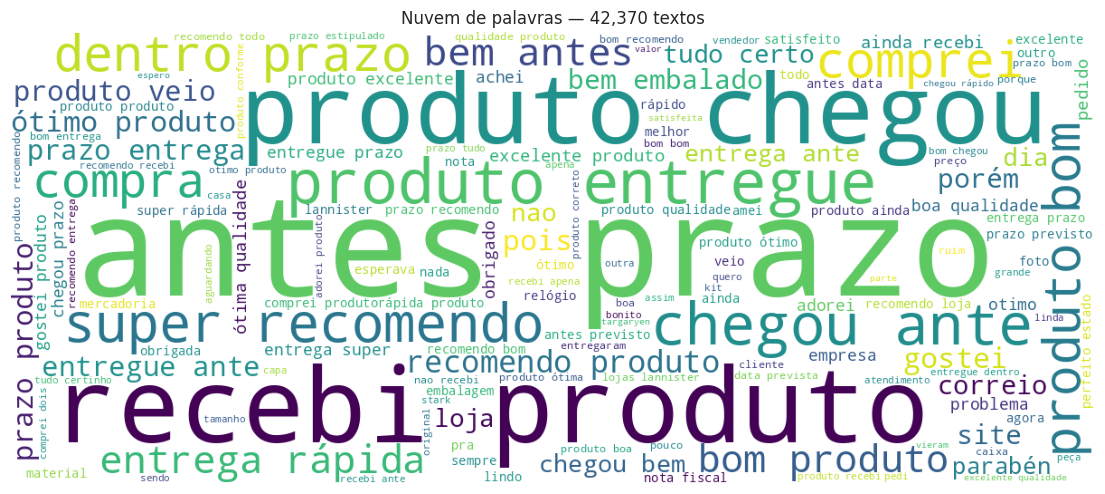

Top bigramas:


,0
antes prazo,4238
recebi produto,1977
produto chegou,1717
produto entregue,1697
chegou antes,1521
super recomendo,1278
dentro prazo,1083
entrega rápida,982
bem antes,974
produto bom,971


In [17]:
stop_pt = set(stopwords.words("portuguese"))

com_texto = avaliacoes[avaliacoes["texto_final_avaliacao"].str.len() > 0].copy()
print("Registros com texto_final_avaliacao:", len(com_texto))
print("Desses, usaram titulo fallback:", com_texto["usou_titulo_fallback"].sum())

tokens_lista = []
for texto in com_texto["texto_final_avaliacao"]:
    t = str(texto).lower()
    t = re.sub(r"http\S+", " ", t)
    t = re.sub(r"[^a-záàâãéèêíïóôõöúçñ\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    tok = [w for w in word_tokenize(t, language="portuguese") if w not in stop_pt and len(w) > 2]
    tokens_lista.append(" ".join(tok))

com_texto = com_texto.assign(tokens=tokens_lista)
corpus = " ".join(com_texto["tokens"])

wc = WordCloud(width=1200, height=500, max_words=150, background_color="white").generate(corpus)
plt.figure(figsize=(14, 6)); plt.imshow(wc); plt.axis("off")
plt.title(f"Nuvem de palavras — {len(com_texto):,} textos"); plt.show()

# Bigramas (base completa)
vec = CountVectorizer(ngram_range=(2, 2), max_features=25, min_df=10)
X = vec.fit_transform(com_texto["tokens"])
bigramas = pd.Series(X.sum(axis=0).A1, index=vec.get_feature_names_out()).sort_values(ascending=False)
print("Top bigramas:"); display(bigramas.head(20))

## 9. Análise de sentimentos

### Por que Transformers é a abordagem principal?

| | Modelo léxico (VADER/LeIA) | Transformers (BERT) |
|---|---------------------------|---------------------|
| Mecanismo | Dicionário + regras | Rede neural + atenção |
| Contexto | Palavra a palavra | Frase inteira (bidirecional) |
| Português | LeIA adapta léxico; VADER é inglês | Modelo multilíngue processa PT **nativamente** |
| Ambiguidade | Fraca | Melhor (“produto bom, entrega ruim”) |

**BERT** gera embeddings contextuais — cada palavra depende das vizinhas. O Transformers é identificado como método **mais robusto e moderno**.

**Modelo:** `nlptown/bert-base-multilingual-uncased-sentiment` (1–5 estrelas, sem `deep_translator`).

**Limitações:** custo computacional; ironia extrema; registros sem texto e sem título recebem score neutro.

**Entrada do modelo:** coluna `texto_final_avaliacao` (comentário prioritário; título quando comentário vazio).

In [14]:
# ==========================================================
# CLASSIFICAÇÃO EM 5 CLASSES
# ==========================================================

def classe_sentimento(estrelas):
    if pd.isna(estrelas):
        return "neutro"

    estrelas = int(estrelas)

    if estrelas == 1:
        return "muito negativo"
    elif estrelas == 2:
        return "negativo"
    elif estrelas == 3:
        return "neutro"
    elif estrelas == 4:
        return "positivo"
    elif estrelas == 5:
        return "muito positivo"

    return "neutro"


def estrelas_para_compound(label, confianca):
    mapa = {
        "1 star": -1.0,
        "2 stars": -0.5,
        "3 stars": 0.0,
        "4 stars": 0.5,
        "5 stars": 1.0
    }
    return mapa.get(label, 0.0) * float(confianca)


def estrelas_para_numero(label):
    try:
        return int(str(label).split()[0])
    except:
        return np.nan

In [19]:
# --- TRANSFORMERS: inferência em 100% dos textos disponíveis ---
from transformers import pipeline
import torch
from tqdm.auto import tqdm

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("AVISO: ative GPU no Colab (Runtime > Change runtime type > T4 GPU)")

NOME_MODELO = "nlptown/bert-base-multilingual-uncased-sentiment"
DEVICE = 0 if torch.cuda.is_available() else -1
LOTE = 64 if torch.cuda.is_available() else 16

classificador = pipeline(
    "sentiment-analysis",
    model=NOME_MODELO,
    tokenizer=NOME_MODELO,
    device=DEVICE,
    truncation=True,
    max_length=512,
)

# ==========================================================
# BASE PARA SENTIMENT ANALYSIS
# ==========================================================

sent = avaliacoes[[
    "review_id",
    "order_id",
    "review_score",
    "texto_final_avaliacao",
    "usou_titulo_fallback"
]].copy()

sent["tf_compound"] = 0.0
sent["tf_estrelas"] = np.nan
sent["tf_label_raw"] = ""
sent["tf_confianca"] = np.nan

# Apenas registros com texto disponível
mask = sent["texto_final_avaliacao"].notna()

idx = sent.index[mask]
textos = sent.loc[idx, "texto_final_avaliacao"].tolist()

print(f"Inferência BERT em {len(textos):,} textos...")
print(f"Destes, {sent.loc[idx, 'usou_titulo_fallback'].sum():,} vieram apenas do título.")

# ==========================================================
# INFERÊNCIA
# ==========================================================

saida = []

for i in tqdm(range(0, len(textos), LOTE), desc="BERT"):
    lote = textos[i:i + LOTE]

    try:
        saida.extend(classificador(lote))

    except Exception as e:
        print(f"Erro no lote {i}: {e}")

        saida.extend(
            [{"label": "3 stars", "score": 0.5}]
            * len(lote)
        )

# ==========================================================
# PREENCHIMENTO DOS RESULTADOS
# ==========================================================

for i, row_idx in enumerate(idx):

    r = saida[i]

    sent.at[row_idx, "tf_label_raw"] = r["label"]
    sent.at[row_idx, "tf_confianca"] = r["score"]
    sent.at[row_idx, "tf_compound"] = estrelas_para_compound(
        r["label"],
        r["score"]
    )
    sent.at[row_idx, "tf_estrelas"] = estrelas_para_numero(
        r["label"]
    )

# ==========================================================
# CLASSIFICAÇÃO EM 5 CLASSES
# ==========================================================

sent["tf_classe"] = sent["tf_estrelas"].apply(classe_sentimento)

ordem_classes = [
    "muito negativo",
    "negativo",
    "neutro",
    "positivo",
    "muito positivo"
]

sent["tf_classe"] = pd.Categorical(
    sent["tf_classe"],
    categories=ordem_classes,
    ordered=True
)

print("Transformers concluído.")

display(
    sent.loc[
        mask,
        [
            "review_score",
            "texto_final_avaliacao",
            "usou_titulo_fallback",
            "tf_estrelas",
            "tf_compound",
            "tf_classe"
        ]
    ].head(10)
)

print("\nDistribuição das classes:")
display(
    sent["tf_classe"]
    .value_counts()
    .reindex(ordem_classes)
    .to_frame("quantidade")
)

GPU: Tesla T4


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

...

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Transformers concluído.


,review_score,texto_final_avaliacao,usou_titulo_fallback,tf_estrelas,tf_compound,tf_classe
3,5,Recebi bem antes do prazo estipulado.,False,3.0,0.000000,neutro
4,5,Parabéns lojas lannister adorei comprar pela I...,False,5.0,0.538074,muito positivo
9,4,recomendo aparelho eficiente. no site a marca ...,False,4.0,0.194813,positivo
12,4,"Mas um pouco ,travando...pelo valor ta Boa.",False,3.0,0.000000,neutro
15,5,"Super recomendo Vendedor confiável, produto ok...",False,5.0,0.708964,muito positivo
16,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",False,1.0,-0.360026,muito negativo
19,1,Não chegou meu produto Péssimo,False,1.0,-0.956186,muito negativo
22,5,Ótimo Loja nota 10,False,5.0,0.385556,muito positivo
24,5,obrigado pela atençao amim dispensada,False,1.0,-0.444980,muito negativo
27,5,A compra foi realizada facilmente. A entrega f...,False,5.0,0.554259,muito positivo



Distribuição das classes:


,quantidade
tf_classe,
muito negativo,12710
negativo,2599
neutro,59620
positivo,4597
muito positivo,18884


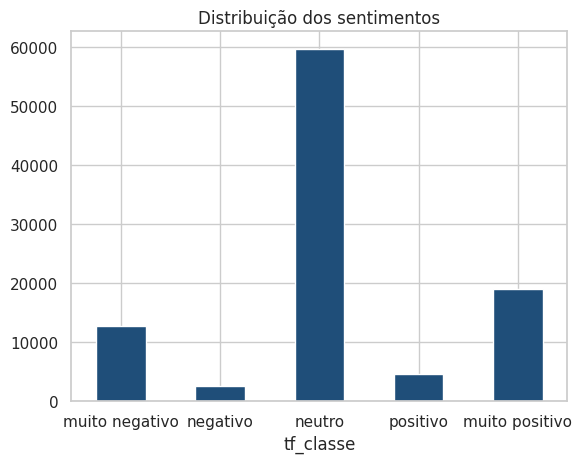

In [37]:
ordem = [
    "muito negativo",
    "negativo",
    "neutro",
    "positivo",
    "muito positivo"
]

(
    sent["tf_classe"]
    .value_counts()
    .reindex(ordem)
    .plot(
        kind="bar",
        color=COR_PRIMARIA
    )
)

plt.title("Distribuição dos sentimentos")
plt.xticks(rotation=0)
plt.show()

**Interpretação:** `tf_estrelas` compara com `review_score`. O fallback de título aumenta cobertura sem distorcer quem já comentou.

### 9.1 Modelos léxicos (somente comparação pedagógica)

VADER e LeIA rodam na **base completa** para contrastar com o BERT. Não usamos tradução externa.

In [21]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
try:
    from LeIA import SentimentIntensityAnalyzer as LeIAAnalyzer
except ImportError:
    from leia import SentimentIntensityAnalyzer as LeIAAnalyzer

vader = SentimentIntensityAnalyzer()
leia = LeIAAnalyzer()

def compound_lex(analisador, texto):
    if not str(texto).strip():
        return 0.0
    return analisador.polarity_scores(str(texto))["compound"]

print("VADER — base completa...")
sent["vader_compound"] = sent["texto_final_avaliacao"].apply(lambda t: compound_lex(vader, t))
sent["vader_classe"] = sent["vader_compound"].apply(classe_sentimento)

print("LeIA — base completa...")
sent["leia_compound"] = sent["texto_final_avaliacao"].apply(lambda t: compound_lex(leia, t))
sent["leia_classe"] = sent["leia_compound"].apply(classe_sentimento)

print("Modelos léxicos concluídos.")

VADER — base completa...
LeIA — base completa...
Modelos léxicos concluídos.


## 10. Comparação de modelos e entrega × sentimento

**Perguntas:**
- Qual modelo alinha melhor com a nota?
- Pedidos atrasados têm mais comentários negativos (Transformers)?

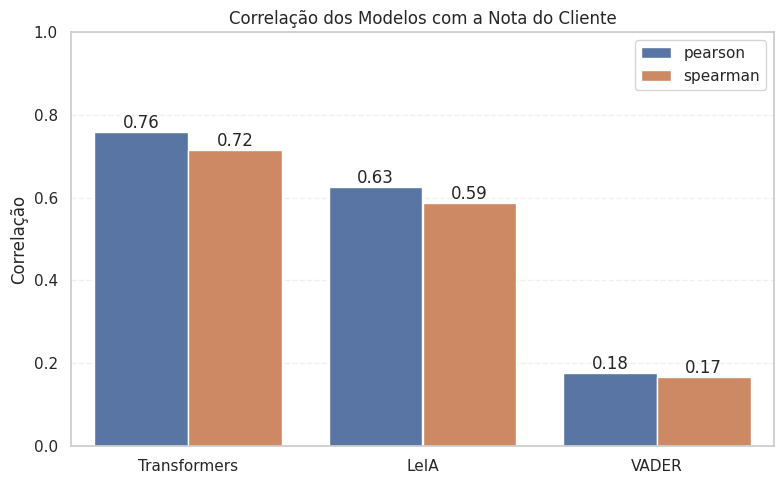

In [45]:
resultado = pd.DataFrame(linhas)

plt.figure(figsize=(8, 5))

resultado_plot = resultado.melt(
    id_vars="modelo",
    value_vars=["pearson", "spearman"],
    var_name="Métrica",
    value_name="Correlação"
)

sns.barplot(
    data=resultado_plot,
    x="modelo",
    y="Correlação",
    hue="Métrica"
)

plt.title("Correlação dos Modelos com a Nota do Cliente")
plt.xlabel("")
plt.ylabel("Correlação")
plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(title="")

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretação das correlações

Foram utilizadas duas métricas para avaliar o alinhamento entre o sentimento identificado pelos modelos e a nota dada pelo cliente:

- **Pearson**: verifica a relação linear entre o score de sentimento e a nota da avaliação. Valores mais altos indicam que, à medida que o sentimento se torna mais positivo, a nota também tende a aumentar.

- **Spearman**: verifica se a classificação das avaliações segue a mesma ordem das notas atribuídas pelos clientes. É uma métrica menos sensível a valores extremos e avalia a consistência do ranqueamento.

Em ambas as métricas, valores mais próximos de **1** indicam melhor desempenho do modelo na representação da satisfação do cliente.

## 11. Incoerências (nota × sentimento)

**Pergunta:** existe comentário positivo com nota baixa (ou o inverso)?  
Detectamos com **Transformers** sobre `texto_final_avaliacao`.

In [13]:
com = sent.dropna(
    subset=["texto_final_avaliacao"]
).copy()

com = com.merge(
    base[
        [
            "order_id",
            "atrasou",
            "faixa_atraso",
            "dias_atraso",
            "customer_state"
        ]
    ],
    on="order_id",
    how="left"
)

def faixa_nota(n):
    if n <= 2: return "baixa"
    if n == 3: return "media"
    return "alta"

com["faixa_nota"] = com["review_score"].apply(faixa_nota)
com["faixa_sent"] = com["tf_compound"].apply(
    lambda x: "baixa" if x <= -0.1 else ("media" if x < 0.1 else "alta")
)
com["incoerente"] = com["faixa_nota"] != com["faixa_sent"]

print(f"Taxa de incoerência (Transformers): {com['incoerente'].mean()*100:.2f}%")
print(f"Divergência >= 2 estrelas (predito vs real): {(com['tf_estrelas'] - com['review_score']).abs().ge(2).mean()*100:.2f}%")

print("\n--- Exemplos: texto positivo, nota baixa ---")
display(com[(com["review_score"] <= 2) & (com["tf_compound"] >= 0.3)][
    ["review_score", "tf_estrelas", "tf_compound", "texto_final_avaliacao", "usou_titulo_fallback"]].head(5))

print("\n--- Exemplos: texto negativo, nota alta ---")
display(com[(com["review_score"] >= 4) & (com["tf_compound"] <= -0.3)][
    ["review_score", "tf_estrelas", "tf_compound", "texto_final_avaliacao", "usou_titulo_fallback"]].head(5))

print("Possíveis causas: sarcasmo, foco em entrega vs produto, nota automática/hábito, limite do modelo.")

NameError: name 'sent' is not defined

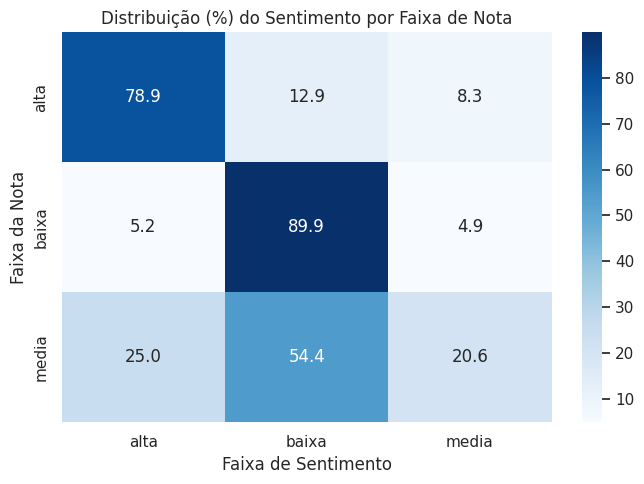

In [52]:
conf_pct = pd.crosstab(
    com["faixa_nota"],
    com["faixa_sent"],
    normalize="index"
) * 100

plt.figure(figsize=(7, 5))

sns.heatmap(
    conf_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Distribuição (%) do Sentimento por Faixa de Nota")
plt.xlabel("Faixa de Sentimento")
plt.ylabel("Faixa da Nota")

plt.tight_layout()
plt.show()

**Insight:** O modelo demonstrou alta capacidade de identificar avaliações claramente positivas e negativas, com 78,9% de concordância para notas altas e 89,9% para notas baixas. As maiores divergências ocorreram nas avaliações de nota média, que frequentemente foram interpretadas como sentimentos positivos ou negativos, indicando maior ambiguidade nesse grupo.

## 12. Síntese visual — coerência nota × sentimento

In [12]:
ct = pd.crosstab(
    com["review_score"],
    com["tf_classe"],
    normalize="index"
)

ct = ct.reindex(
    columns=ordem_classes,
    fill_value=0
)

ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="RdYlGn"
)

plt.title("Distribuição dos sentimentos em cada nota")
plt.xlabel("Nota")
plt.ylabel("Proporção")

plt.legend(
    title="Sentimento",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

NameError: name 'com' is not defined

## 14. Conclusão

### Resposta ao problema de negócio

O projeto investigou a relação entre **nota** e **texto** nas avaliações de um marketplace. Com dados tratados e análise em **100% da base**, concluímos:

1. **Prazo de entrega importa:** a correlação entre `dias_atraso` e `review_score` e a queda da nota média em pedidos atrasados mostram que **logística é driver de insatisfação** — alinhado à ênfase do professor.

2. **Sentimento confirma o padrão:** pedidos atrasados apresentam `tf_compound` mais baixo e maior proporção de classe negativa (Transformers), reforçando que atraso não afeta só a nota, mas também o **tom do comentário**.

3. **Dimensão regional:** estados com mais pedidos nem sempre têm melhor nota; combinar volume, `% atraso` e `nota_media` evidencia heterogeneidade na experiência do cliente.

4. **Nota ≠ texto sempre:** a taxa de incoerência (nota vs. sentimento BERT) mostra que estrelas e comentários são **complementares**. O fallback de **título** quando o comentário está vazio melhorou a cobertura textual sem distorcer quem já escreveu.

5. **Modelo de sentimento:** **Transformers (BERT multilíngue)** superou VADER/LeIA em alinhamento com a nota, por capturar **contexto** em português, sem tradução externa.

### Evidências-chave

| Evidência | Indicador |
|-----------|-----------|
| Impacto do atraso na nota | Correlação + nota média atrasado vs. no prazo |
| Impacto do atraso no sentimento | `tf_compound` e % negativo por `atrasou` |
| Região sensível | Estado com maior atraso / menor nota |
| Incoerência | % nota × sentimento divergentes |

### Limitações

- Inferência BERT exige GPU e tempo; ironia e gírias ainda falham; viés de notas 5; títulos curtos podem ser ambíguos.

### Recomendações

- Monitorar trimestres e estados com pior `% atraso`; priorizar SAC em avaliações com sentimento negativo e nota alta (incoerência); usar Transformers como motor de alerta textual.

---

**Referências:** PII1 — Prof. Felipe A. Camargo; Hutto & Gilbert (2014); Hugging Face; `nlptown/bert-base-multilingual-uncased-sentiment`.